# 03 - Data Preprocessing

This notebook is part of the Blood Donation Prediction project.

# 6. DATA PREPROCESSING

## 6.1. CHECKING NULL VALUES

In [ ]:
#CHECKING NULL VALUE
Data.isnull().sum()

,0
Months since Last Donation,0
Number of Donations,0
Total Volume Donated (c.c.),0
Months since First Donation,0
Made Donation in March 2007,0


## 6.2. CORRELATION

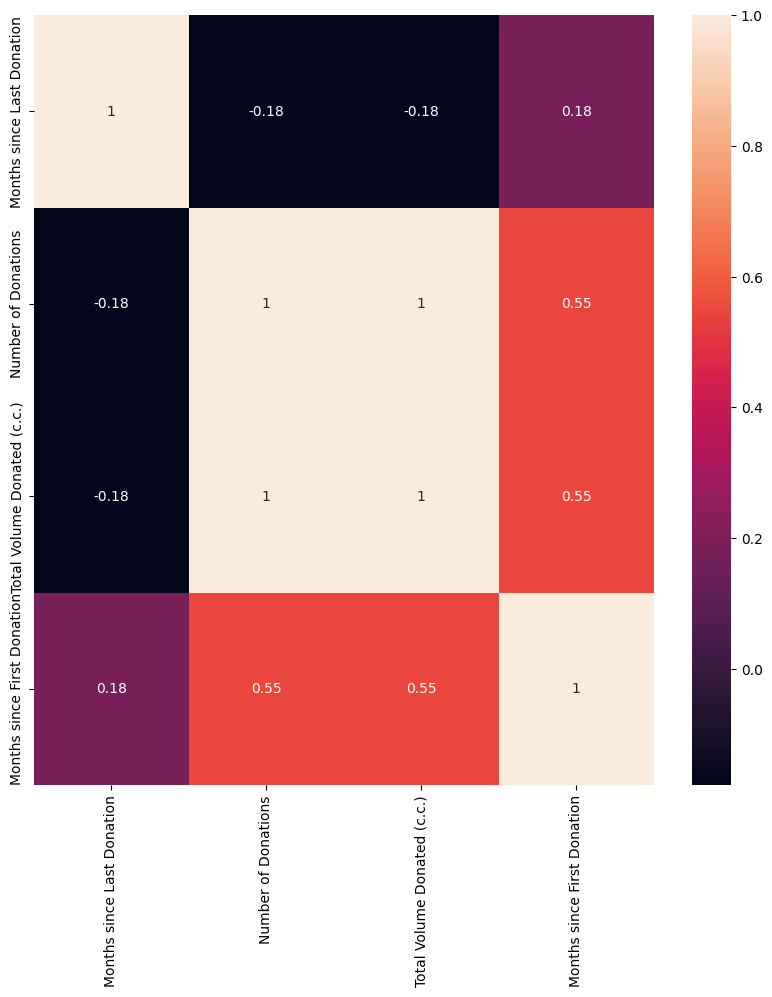

In [ ]:
# Check for correlation to avoid multicollinearity
numer=Data.select_dtypes(include=['int','float'])
plt.figure(figsize=(10,10))
sns.heatmap(data=numer.iloc[:,:-1].corr(),annot=True)
plt.show()

In [ ]:
Data.corr()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
Months since Last Donation,1.000000,-0.177813,-0.177813,0.177292,-0.254092
Number of Donations,-0.177813,1.000000,1.000000,0.548599,0.166417
Total Volume Donated (c.c.),-0.177813,1.000000,1.000000,0.548599,0.166417
Months since First Donation,0.177292,0.548599,0.548599,1.000000,-0.121118
Made Donation in March 2007,-0.254092,0.166417,0.166417,-0.121118,1.000000


## 6.3. HANDLING THE OUTLIERS

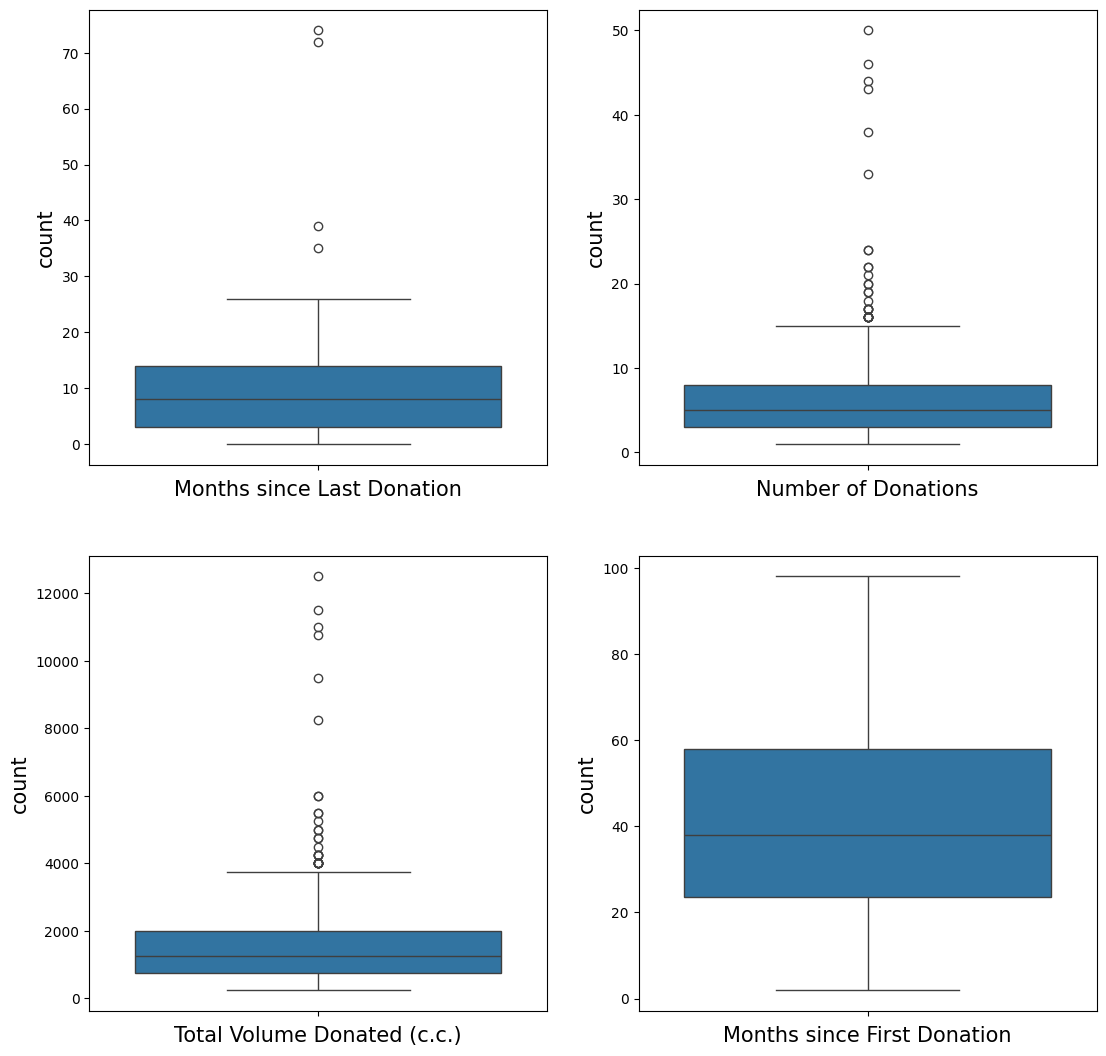

In [ ]:
#checking the outliers
numout=Data.select_dtypes(exclude="O").iloc[:,:-1]
plt.figure(figsize=(13,13),facecolor='white')
plotnumber=1
for i in numout.columns:
    if plotnumber<=4:
        ax=plt.subplot(2,2,plotnumber)
        sns.boxplot(numout[i])
        plt.xlabel(i,fontsize=15)
        plt.ylabel('count',fontsize=15)
    plotnumber=plotnumber+1

plt.show()

In [ ]:
# Handling the outliers

from scipy.stats.mstats import winsorize

winsor_limits = {'Months since Last Donation': (0, 0.01),
                 'Number of Donations': (0, 0.07),
                 'Total Volume Donated (c.c.)': (0, 0.07),
                 }

for col, lim in winsor_limits.items():
    Data[col] = winsorize(Data[col],limits=lim)

#### INSIGHTS

--> The outliers were handled by winsorizing the top 1% of values in Months since Last Donation and the top 7% of values in Number of Donations
and Total Volume Donated (c.c.), after running multiple iterations with different limits to identify the optimal thresholds
where extreme values were effectively adjusted while retaining the overall data distribution.

--> Additionally, no outliers were found in the Months since First Donation column, so it was not modified.

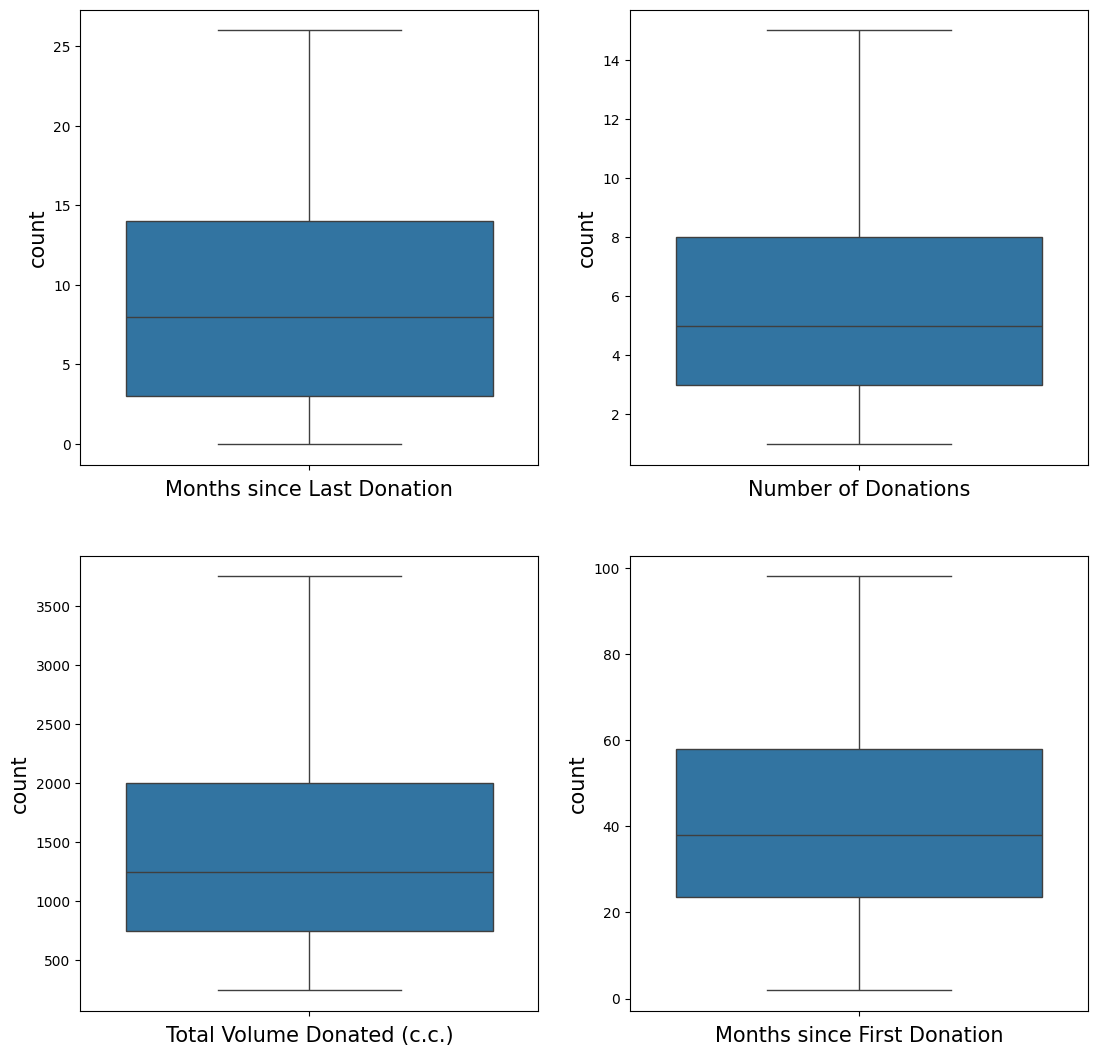

In [ ]:
# After handling the outliers and checking
numout=Data.select_dtypes(exclude="O").iloc[:,:-1]
plt.figure(figsize=(13,13),facecolor='white')
plotnumber=1
for i in numout.columns:
    if plotnumber<=4:
        ax=plt.subplot(2,2,plotnumber)
        sns.boxplot(numout[i])
        plt.xlabel(i,fontsize=15)
        plt.ylabel('count',fontsize=15)
    plotnumber=plotnumber+1

plt.show()


## 6.4. CLASS IMBALANCE CHECKING

In [ ]:
# Checking the value counts of the target column
class_counts=Data["Made Donation in March 2007"].value_counts()
class_counts

,count
Made Donation in March 2007,
0,305
1,118


In [ ]:
# Imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
imbalance_ratio

2.5847457627118646

#### INSIGHTS

Applying SMOTE to balance the class distribution (ratio 2.58) led to a decrease in accuracy, so it was not implemented.

## 6.5. SKEWNESS HANDLING

In [ ]:
#checking for skewness
skewness_values=Data[Data.columns[:-1]].skew()
print(skewness_values)


Months since Last Donation     0.610018
Number of Donations            0.871248
Total Volume Donated (c.c.)    0.871248
Months since First Donation    0.575577
dtype: float64


In [ ]:
# Square root transformation
Data['Months since First Donation']=np.sqrt(Data['Months since First Donation'])

#### INSIGHTS

The square root transformation was applied to Months since First Donation because it is effective in reducing right skewness while preserving the relative order of values.

In [ ]:
# Log transformation
Data[['Number of Donations','Total Volume Donated (c.c.)','Months since Last Donation']]=np.log1p(Data[['Number of Donations','Total Volume Donated (c.c.)','Months since Last Donation']])

#### INSIGHTS

The log transformation (log1p) was applied to Number of Donations, Total Volume Donated (c.c.), and Months since Last Donation because it effectively reduces right skewness, compresses the range of large values, and stabilizes variance.

In [ ]:
# Verifying after skewness handling
print(Data[Data.columns[:-1]].skew())

Months since Last Donation    -0.172215
Number of Donations           -0.006604
Total Volume Donated (c.c.)   -0.267369
Months since First Donation   -0.072977
dtype: float64


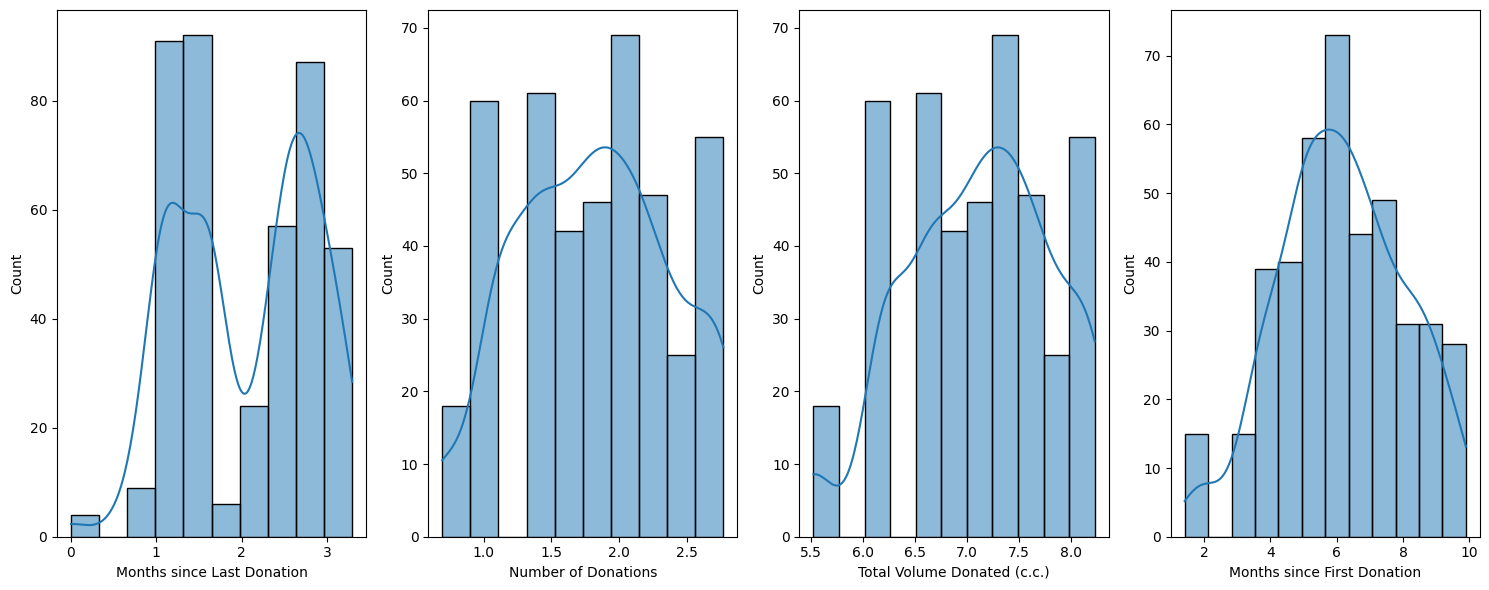

In [ ]:
# Graph after skewness handling
plt.figure(figsize=(15,6),facecolor='white')
plotnumber=1
for column in Data.columns[:-1]:
    if plotnumber<=4:
        ax=plt.subplot(1,4,plotnumber)
        sns.histplot(Data[column],kde=True)
    plotnumber+=1
plt.tight_layout()

## 6.6. SCALING THE NUMERICAL COLUMNS

In [ ]:
#extracting numerical features to scale
X=Data.drop(columns=['Made Donation in March 2007'])

In [ ]:
X

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation
0,1.098612,2.772589,8.229778,9.899495
1,0.000000,2.639057,8.086718,5.291503
2,0.693147,2.772589,8.229778,5.916080
3,1.098612,2.772589,8.229778,6.708204
4,0.693147,2.772589,8.229778,8.774964
...,...,...,...,...
566,3.178054,0.693147,5.525453,4.795832
572,2.833213,1.386294,6.621406,9.273618
573,3.091042,1.098612,6.216606,7.211103
574,3.295837,0.693147,5.525453,6.244998


In [ ]:
# Initializing MinMaxScaler
Scaling=MinMaxScaler()

In [ ]:
# Scale the features
x_scale=Scaling.fit_transform(X)
scaled_data=pd.DataFrame(x_scale,columns=X.columns)
scaled_data

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation
0,0.333333,1.000000,1.000000,1.000000
1,0.000000,0.935785,0.947100,0.456943
2,0.210310,1.000000,1.000000,0.530550
3,0.333333,1.000000,1.000000,0.623903
4,0.210310,1.000000,1.000000,0.867473
...,...,...,...,...
418,0.964263,0.000000,0.000000,0.398527
419,0.859634,0.333333,0.405259,0.926240
420,0.937863,0.194988,0.255573,0.683170
421,1.000000,0.000000,0.000000,0.569313


In [ ]:
x=scaled_data #numercial column

#extracting dependent feature from the data(i.e.target column)
y=Data['Made Donation in March 2007']

In [ ]:
y #Target Column

,Made Donation in March 2007
0,1
1,1
2,1
3,1
4,0
...,...
566,1
572,0
573,0
574,0
